In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import logsumexp
import pickle
import json
import os
import time
from plotting_functions import plot_method_comparison, plot_gillespie_nmc_comparison
from saving_experiments import save_samples, load_samples, save_samples_summary
from main_code import run_diffusion_experiment, add_gillespie_reverse, add_tau_leap_reverse
from add_methods_utils import add_methods_to_lightweight_file, add_method_to_lightweight

# Test: $R^c = R + \hat{R}$ vs  $R^c = R$ 

In [ ]:
# Define random masking methods
random_masking_methods = []

# Test different tau_c values
for tau_c in [1, 0.6, 0.4, 0.2]:
    # With reverse correction (apply_reverse=True)
    random_masking_methods.append({
        'type': 'tau_leap',
        'tau': 0.4,
        'corrector': True,
        'corrector_method': 'random_masking',
        'corrector_start': 1.0,
        'corrector_hyperparameters': {
            'n_corr': 1,
            'tau_c': tau_c,
            'apply_reverse': True
        }
    })
    
    # Forward only (apply_reverse=False)
    random_masking_methods.append({
        'type': 'tau_leap',
        'tau': 0.4,
        'corrector': True,
        'corrector_method': 'random_masking',
        'corrector_start': 1.0,
        'corrector_hyperparameters': {
            'n_corr': 1,
            'tau_c': tau_c,
            'apply_reverse': False
        }
    })

# Add them to the file
print("Adding random masking methods to gillespie_nmc_300000.pkl...")
results = add_methods_to_lightweight_file(
    'gillespie_nmc_300000.pkl',
    random_masking_methods
)

print(f"\n✓ Added {len(results['methods_added'])} random masking methods!")
print("Methods added:")
for method in results['methods_added']:
    print(f"  - {method}")

# Show breakdown
print("\nBreakdown:")
with_reverse = [m for m in results['methods_added'] if 'fwd_only' not in m]
fwd_only = [m for m in results['methods_added'] if 'fwd_only' in m]
print(f"  With reverse correction: {len(with_reverse)}")
print(f"  Forward only: {len(fwd_only)}")

Adding random masking methods to gillespie_nmc_300000.pkl...
ADDING METHODS TO LIGHTWEIGHT SAVE

Loading: gillespie_nmc_300000.pkl
Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 11 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
✓ Lightweight format confirmed

Parameters: N=10, L=3, beta=5.0, T=3.5, n_mc=300000
Existing methods (11): ['gillespie', 'tau_leap_0.1', 'tau_leap_0.01', 'tau_leap_0.008', 'tau_leap_0.005', 'tau_leap_1.5', 'tau_leap_1', 'tau_leap_0.5', 'tau_leap_0.4', 'tau_leap_0.3', 'tau_leap_0.2']

Adding 8 new methods...

[1/8] Adding: tau=0.4, random_masking
Running tau-leaping (tau=0.4) reverse process...
  With corrector: random_masking, start=1.0
  Corrector hyperparameters: {'n_corr': 1, 'tau_c': 1, 'apply_reverse': True}
  Tau-leap particle 0/300000
  Tau-leap particl

Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 19 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
Computing Hellinger distances from joint PMFs...

Generating plot for methods: ['gillespie', 'tau_leap_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2']
Time range: [0.000, 3.500]
Plot saved to: random_masking_tauc_comparison.png


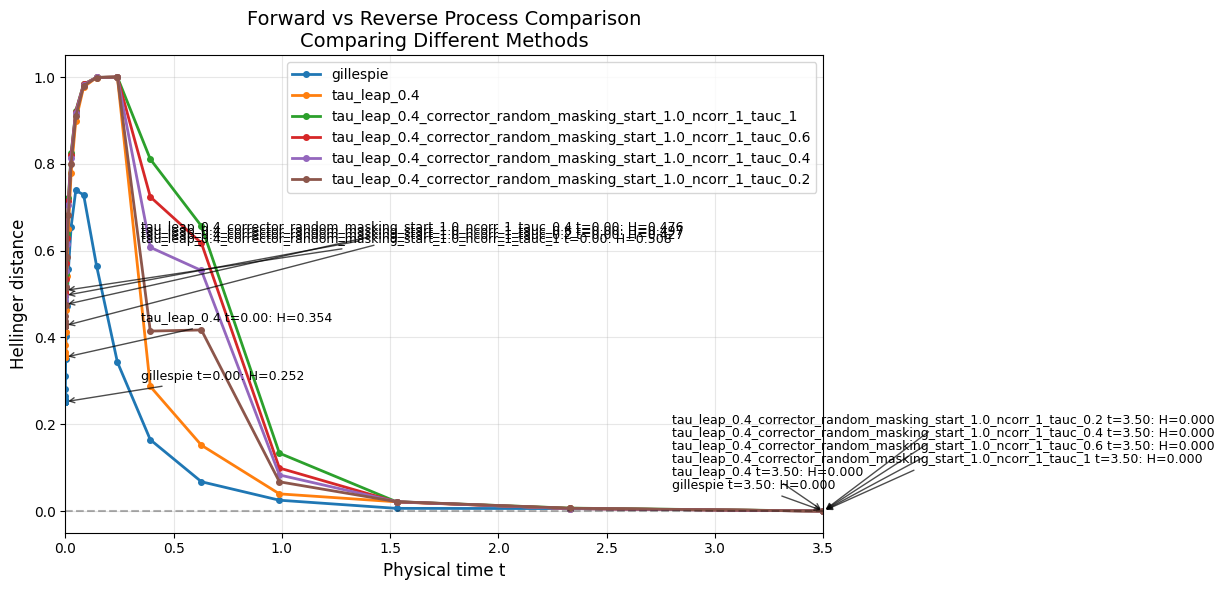

In [20]:
data, metadata = load_samples('gillespie_nmc_300000.pkl')

# Plot all methods
a = plot_method_comparison(
    data,
    methods=['gillespie', 'tau_leap_0.4','tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2' ],  # None = plot all methods
    filename='random_masking_tauc_comparison.png',
    show_annotations=True, return_distances=True
)

Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 19 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
Computing Hellinger distances from joint PMFs...

Generating plot for methods: ['gillespie', 'tau_leap_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only']
Time range: [0.000, 3.500]
Plot saved to: random_masking_tauc_comparison_fwd_only.png


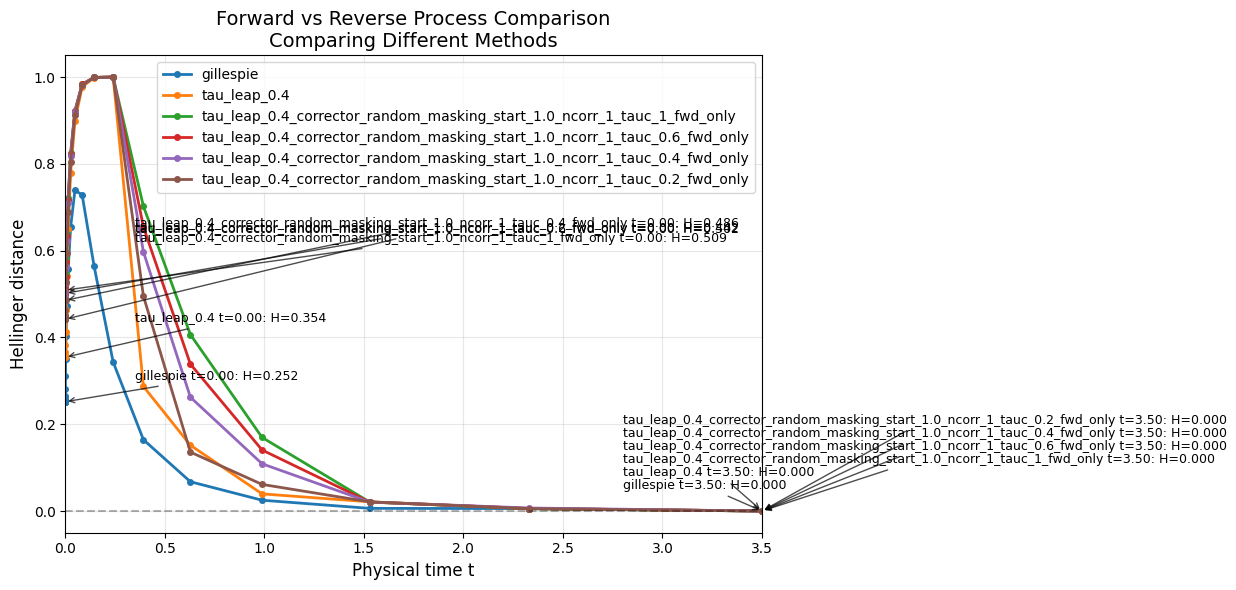

In [24]:
data, metadata = load_samples('gillespie_nmc_300000.pkl')

# Plot all methods
b = plot_method_comparison(
    data,
    methods=['gillespie', 'tau_leap_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only' ],  # None = plot all methods
    filename='random_masking_tauc_comparison_fwd_only.png',
    show_annotations=True,
    return_distances=True
)

In [25]:
print(f"gillespie: {b['gillespie'][0.0]:.2f}")
print(f"tau_leap_0.4: {b['tau_leap_0.4'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_1_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.6_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.4_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.2_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only'][0.0]:.2f}")

gillespie: 0.25
tau_leap_0.4: 0.35
'tau_leap_0.4_tauc_1_fwd_only': 0.51
'tau_leap_0.4_tauc_0.6_fwd_only': 0.50
'tau_leap_0.4_tauc_0.4_fwd_only': 0.49
'tau_leap_0.4_tauc_0.2_fwd_only': 0.44


In [23]:
print(f"gillespie: {a['gillespie'][0.0]:.2f}")
print(f"tau_leap_0.4: {a['tau_leap_0.4'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_1': {a['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.6': {a['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.4': {a['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.2': {a['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2'][0.0]:.2f}")

gillespie: 0.25
tau_leap_0.4: 0.35
'tau_leap_0.4_tauc_1': 0.51
'tau_leap_0.4_tauc_0.6': 0.50
'tau_leap_0.4_tauc_0.4': 0.48
'tau_leap_0.4_tauc_0.2': 0.43


# Test: different $\tau_c$ for  $R^c = R$ 

In [26]:
# Define random masking methods
random_masking_methods = []

# Test different tau_c values
for tau_c in [0.1, 0.05, 0.01]:

    
    # Forward only (apply_reverse=False)
    random_masking_methods.append({
        'type': 'tau_leap',
        'tau': 0.4,
        'corrector': True,
        'corrector_method': 'random_masking',
        'corrector_start': 1.0,
        'corrector_hyperparameters': {
            'n_corr': 1,
            'tau_c': tau_c,
            'apply_reverse': False
        }
    })

# Add them to the file
print("Adding random masking methods to gillespie_nmc_300000.pkl...")
results = add_methods_to_lightweight_file(
    'gillespie_nmc_300000.pkl',
    random_masking_methods
)

print(f"\n✓ Added {len(results['methods_added'])} random masking methods!")
print("Methods added:")
for method in results['methods_added']:
    print(f"  - {method}")

# Show breakdown
print("\nBreakdown:")
with_reverse = [m for m in results['methods_added'] if 'fwd_only' not in m]
fwd_only = [m for m in results['methods_added'] if 'fwd_only' in m]
print(f"  With reverse correction: {len(with_reverse)}")
print(f"  Forward only: {len(fwd_only)}")

Adding random masking methods to gillespie_nmc_300000.pkl...
ADDING METHODS TO LIGHTWEIGHT SAVE

Loading: gillespie_nmc_300000.pkl
Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 19 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
✓ Lightweight format confirmed

Parameters: N=10, L=3, beta=5.0, T=3.5, n_mc=300000
Existing methods (19): ['gillespie', 'tau_leap_0.1', 'tau_leap_0.01', 'tau_leap_0.008', 'tau_leap_0.005', 'tau_leap_1.5', 'tau_leap_1', 'tau_leap_0.5', 'tau_leap_0.4', 'tau_leap_0.3', 'tau_leap_0.2', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_onl

Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 22 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
Computing Hellinger distances from joint PMFs...

Generating plot for methods: ['gillespie', 'tau_leap_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.01_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.05_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only']
Time range: [-0.100, 0.700]
Plot saved to: random_masking_tauc_comparison_fwd_only.png


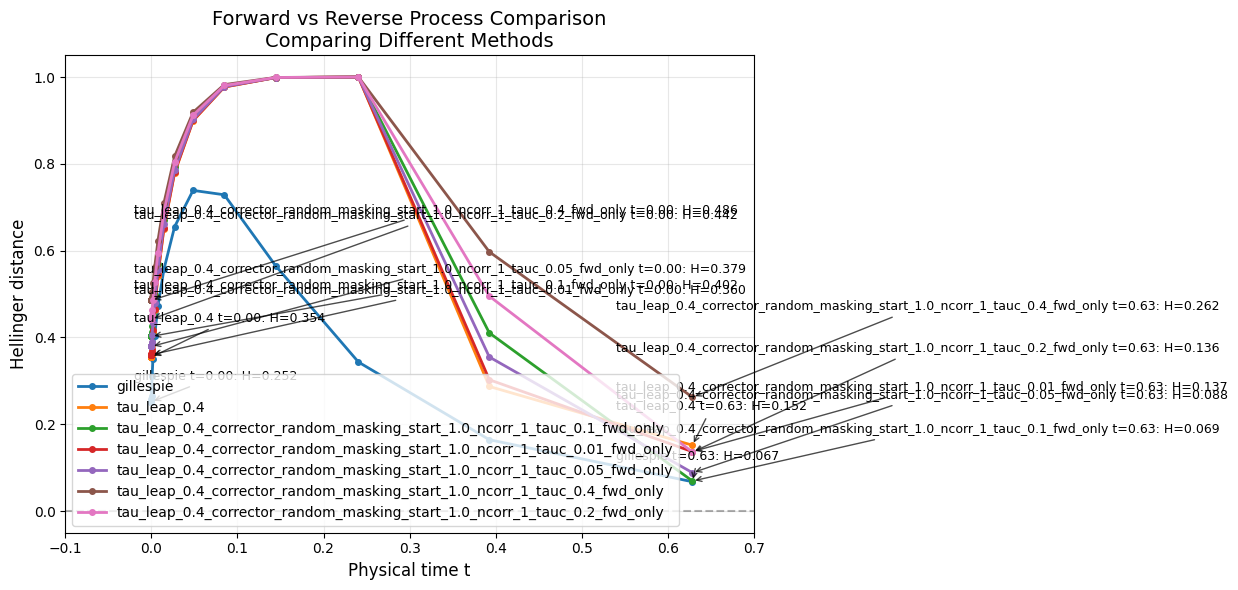

In [28]:
data, metadata = load_samples('gillespie_nmc_300000.pkl')

# Plot all methods
b = plot_method_comparison(
    data,
    methods=['gillespie', 'tau_leap_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.01_fwd_only','tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.05_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only' ], 
    filename='random_masking_tauc_comparison_fwd_only.png',
    show_annotations=True,
    time_start= -0.1,
    time_end=0.7,
    return_distances=True
)

In [29]:
print(f"gillespie: {b['gillespie'][0.0]:.2f}")
print(f"tau_leap_0.4: {b['tau_leap_0.4'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_1_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.6_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.4_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.2_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.1_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.05_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.05_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.01_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.01_fwd_only'][0.0]:.2f}")

gillespie: 0.25
tau_leap_0.4: 0.35
'tau_leap_0.4_tauc_1_fwd_only': 0.51
'tau_leap_0.4_tauc_0.6_fwd_only': 0.50
'tau_leap_0.4_tauc_0.4_fwd_only': 0.49
'tau_leap_0.4_tauc_0.2_fwd_only': 0.44
'tau_leap_0.4_tauc_0.1_fwd_only': 0.40
'tau_leap_0.4_tauc_0.05_fwd_only': 0.38
'tau_leap_0.4_tauc_0.01_fwd_only': 0.36


# Grid search tau_c, n_corr, start time

In [ ]:
# Define all parameter combinations
random_masking_methods = []

tau = 0.4
tau_c_values = [1, 0.4, 0.2, 0.05, 0.01, 0.005, 0.001]
n_corr_values = [1, 2, 4]
start_times = [3.5, 2.5, 1.5, 0.5]

# Generate all combinations for forward-only corrector
for tau_c in tau_c_values:
    for n_corr in n_corr_values:
        for start_time in start_times:
            random_masking_methods.append({
                'type': 'tau_leap',
                'tau': tau,
                'corrector': True,
                'corrector_method': 'random_masking',
                'corrector_start': start_time,
                'corrector_hyperparameters': {
                    'n_corr': n_corr,
                    'tau_c': tau_c,
                    'apply_reverse': False  # Forward only
                }
            })

print("=" * 70)
print("ADDING RANDOM MASKING METHODS (FORWARD ONLY)")
print("=" * 70)
print(f"\nParameter grid:")
print(f"  tau: {tau}")
print(f"  tau_c values: {tau_c_values} ({len(tau_c_values)} values)")
print(f"  n_corr values: {n_corr_values} ({len(n_corr_values)} values)")
print(f"  start times: {start_times} ({len(start_times)} values)")
print(f"\nTotal methods to add: {len(tau_c_values)} × {len(n_corr_values)} × {len(start_times)} = {len(random_masking_methods)}")

# Add them to the file
print(f"\nAdding {len(random_masking_methods)} methods to gillespie_nmc_300000.pkl...")
print("This will take a few minutes...")

results = add_methods_to_lightweight_file(
    'gillespie_nmc_300000.pkl',
    random_masking_methods
)

print("\n" + "=" * 70)
print("✓ COMPLETE!")
print("=" * 70)
print(f"\nAdded: {len(results['methods_added'])} methods")
print(f"Total methods in file: {results['total_methods']}")
print(f"File size: {results['file_size_mb']:.2f} MB")

# Show some example method names
print("\nExample methods added:")
for i, method in enumerate(results['methods_added'][:5], 1):
    print(f"  {i}. {method}")
if len(results['methods_added']) > 5:
    print(f"  ... and {len(results['methods_added']) - 5} more")

ADDING RANDOM MASKING METHODS (FORWARD ONLY)

Parameter grid:
  tau: 0.4
  tau_c values: [1, 0.4, 0.2, 0.05, 0.01, 0.005, 0.001] (7 values)
  n_corr values: [1, 2, 4] (3 values)
  start times: [3.5, 2.5, 1.5, 0.5] (4 values)

Total methods to add: 7 × 3 × 4 = 84

Adding 84 methods to gillespie_nmc_300000.pkl...
This will take a few minutes...
ADDING METHODS TO LIGHTWEIGHT SAVE

Loading: gillespie_nmc_300000.pkl
Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 22 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
✓ Lightweight format confirmed

Parameters: N=10, L=3, beta=5.0, T=3.5, n_mc=300000
Existing methods (22): ['gillespie', 'tau_leap_0.1', 'tau_leap_0.01', 'tau_leap_0.008', 'tau_leap_0.005', 'tau_leap_1.5', 'tau_leap_1', 'tau_leap_0.5', 'tau_leap_0.4', 'tau_leap_0.3', 'tau_leap_0.2'

Loading data...
Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 106 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
Found 91 random masking (forward only) methods

Computing Hellinger distances...
Computing Hellinger distances from joint PMFs...

Generating plot for methods: ['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.05_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_t

/Users/lorenllagami/Desktop/MastersThesis/Correctors_Discrete_Diffusion/plotting_functions.py:151: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Plot saved to: random_masking_all.png


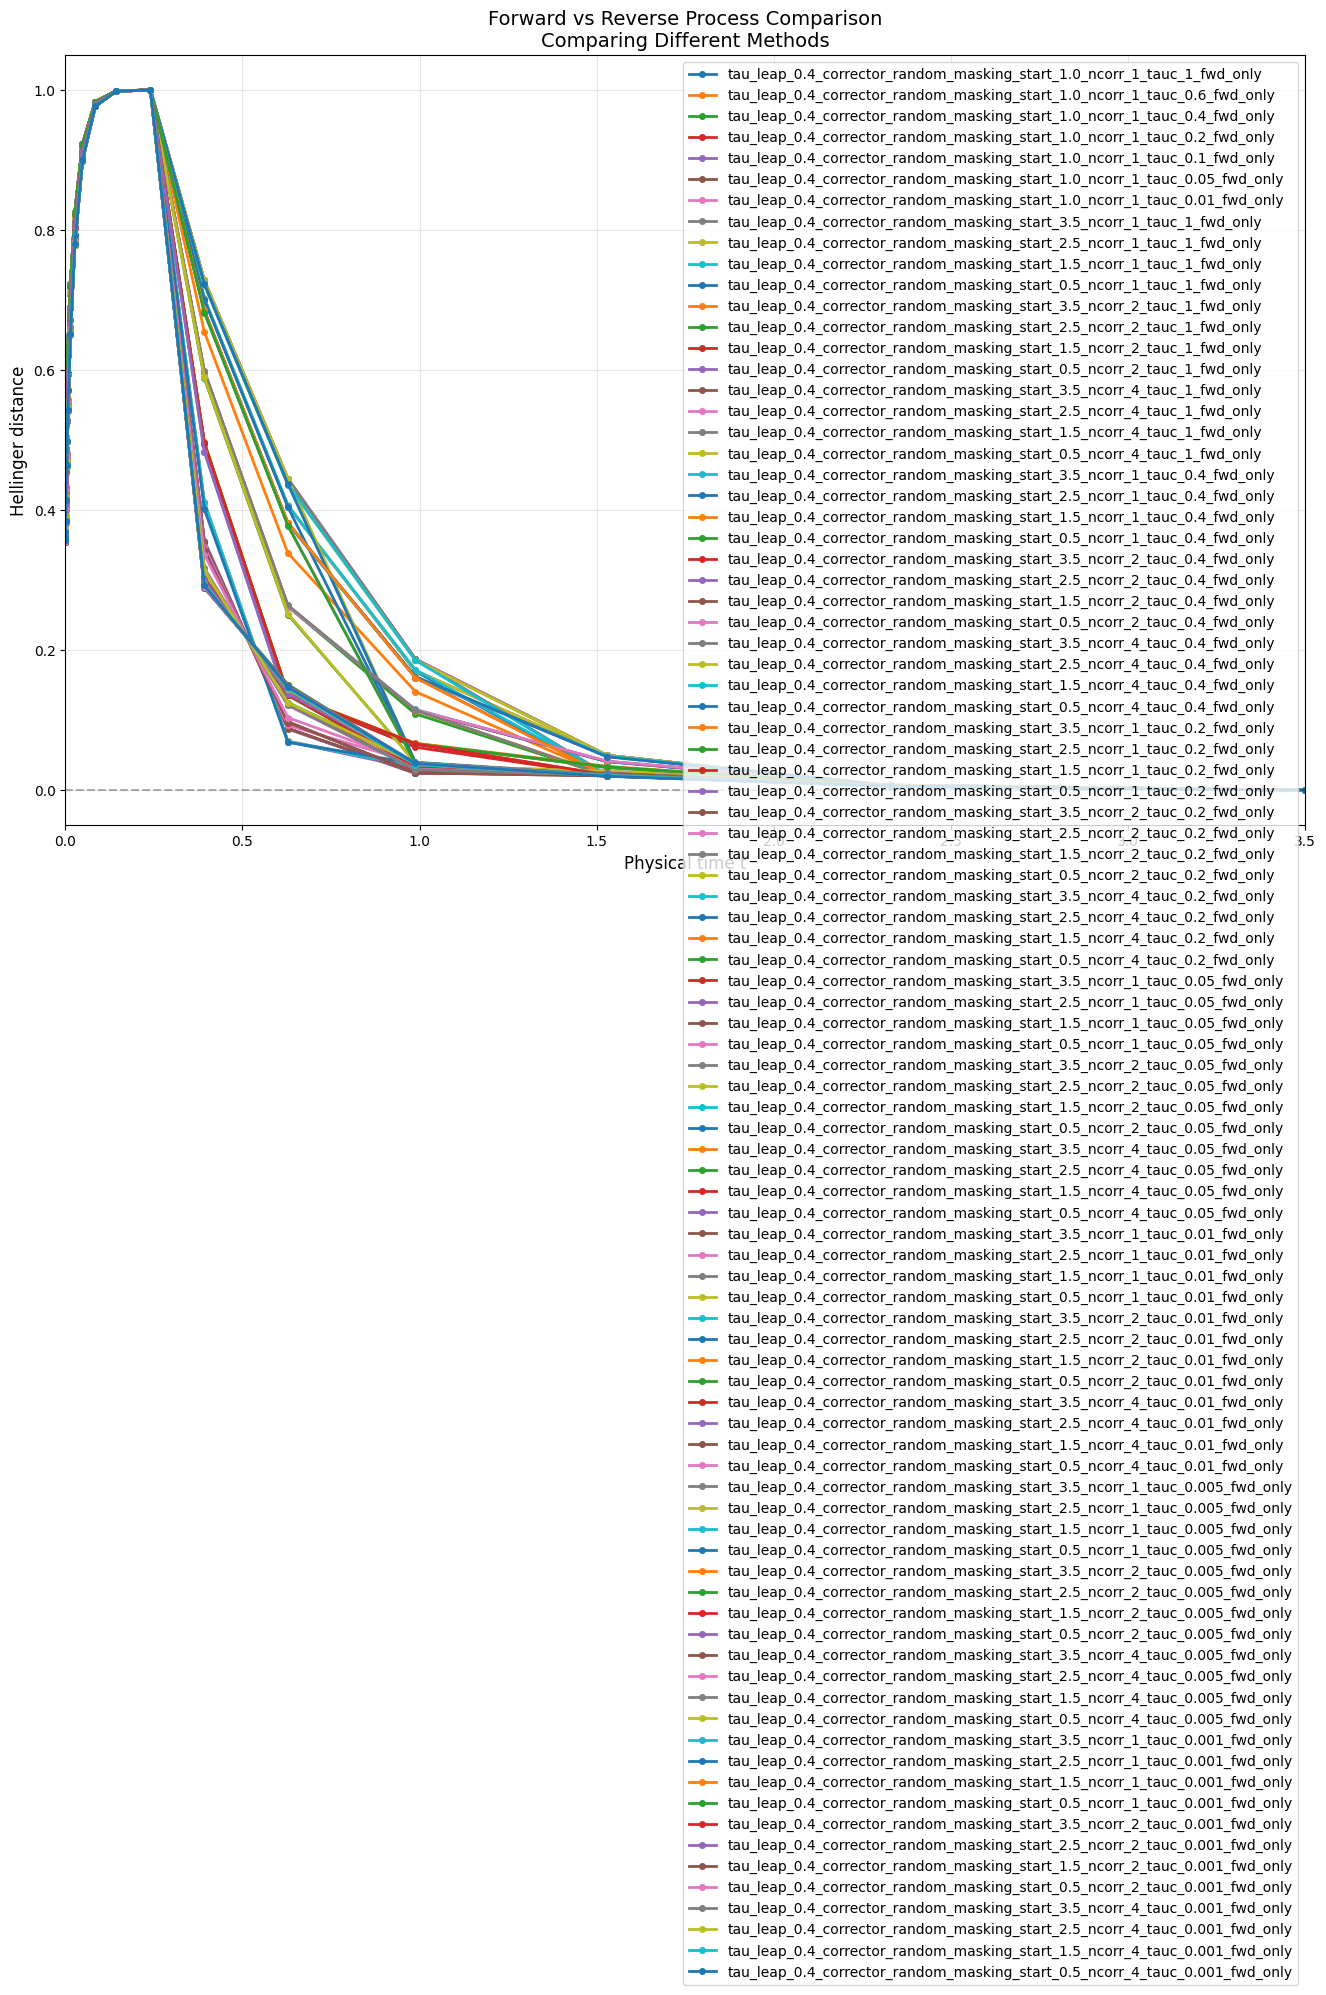


Checkpoint closest to t=0: 0.000000

HELLINGER DISTANCES AT t=0

Rank   Hellinger    Method
----------------------------------------------------------------------------------------------------
1      0.354166     tau_leap_0.4_corrector_random_masking_start_1.5_ncorr_2_tauc_0.001_fwd_only
2      0.355163     tau_leap_0.4_corrector_random_masking_start_2.5_ncorr_1_tauc_0.001_fwd_only
3      0.355392     tau_leap_0.4_corrector_random_masking_start_2.5_ncorr_2_tauc_0.001_fwd_only
4      0.355739     tau_leap_0.4_corrector_random_masking_start_3.5_ncorr_1_tauc_0.001_fwd_only
5      0.355849     tau_leap_0.4_corrector_random_masking_start_0.5_ncorr_2_tauc_0.001_fwd_only
6      0.355886     tau_leap_0.4_corrector_random_masking_start_0.5_ncorr_1_tauc_0.001_fwd_only
7      0.355896     tau_leap_0.4_corrector_random_masking_start_1.5_ncorr_1_tauc_0.001_fwd_only
8      0.356242     tau_leap_0.4_corrector_random_masking_start_3.5_ncorr_2_tauc_0.001_fwd_only
9      0.356662     tau_leap_0.4_corre

In [32]:
from saving_experiments import load_samples
from plotting_functions import plot_method_comparison
import numpy as np

# Load data
print("Loading data...")
data, metadata = load_samples('gillespie_nmc_300000.pkl')

# Get all random masking methods
all_methods = list(data['reverse_pmfs'].keys())
random_masking_methods = [m for m in all_methods if 'random_masking' in m and 'fwd_only' in m]

print(f"Found {len(random_masking_methods)} random masking (forward only) methods")

# Use plot function to get distances (with return_distances=True)
print("\nComputing Hellinger distances...")
all_distances = plot_method_comparison(
    data,
    methods=random_masking_methods,
    filename='random_masking_all.png',
    figsize=(16, 10),
    show_annotations=False,
    return_distances=True  # ← This returns the distances dict
)

# Get checkpoint closest to t=0
times = data['times']
t_zero = times[np.argmin(np.abs(times - 0.0))]

print(f"\nCheckpoint closest to t=0: {t_zero:.6f}")

# Extract Hellinger at t=0 for all methods
print("\n" + "=" * 70)
print("HELLINGER DISTANCES AT t=0")
print("=" * 70)

results = []
for method in random_masking_methods:
    hellinger_at_t0 = all_distances[method][float(t_zero)]
    results.append({
        'method': method,
        'hellinger': hellinger_at_t0
    })

# Sort by Hellinger
results.sort(key=lambda x: x['hellinger'])

# Print results
print(f"\n{'Rank':<6} {'Hellinger':<12} {'Method'}")
print("-" * 100)

for i, result in enumerate(results, 1):
    print(f"{i:<6} {result['hellinger']:<12.6f} {result['method']}")

# Summary statistics
hellinger_values = [r['hellinger'] for r in results]
print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(f"Best (lowest):   {min(hellinger_values):.6f}")
print(f"Worst (highest): {max(hellinger_values):.6f}")
print(f"Mean:            {np.mean(hellinger_values):.6f}")
print(f"Median:          {np.median(hellinger_values):.6f}")
print(f"Std Dev:         {np.std(hellinger_values):.6f}")

# Best configuration
print("\n" + "=" * 70)
print("BEST CONFIGURATION")
print("=" * 70)
print(f"Method: {results[0]['method']}")
print(f"Hellinger at t=0: {results[0]['hellinger']:.6f}")

# Worst configuration
print("\n" + "=" * 70)
print("WORST CONFIGURATION")
print("=" * 70)
print(f"Method: {results[-1]['method']}")
print(f"Hellinger at t=0: {results[-1]['hellinger']:.6f}")